# Análisis exploratorio de datos sobre exoplanetas

## Equipo 5 - Planetas análogos

* Cristóbal Castro Riquelme
* Catalina Echeverría
* Vanessa Meza
* Antonia Morales



# 1. Introducción y contexto

Desde el descubrimiento del primer exoplaneta en el año 1992, se ha instalado tanto en la opinión pública, como en la comunidad científica, la pregunta sobre la existencia de vida en otros planetas. Desde entonces, la astrofisica contemporánea se ha avocado a desarrollar nuevas teorías y tecnologías para optimizar la búsqueda de posible vida extraterrestre más allá del sistema solar.

En este contexto, el análisis de datos es una práctica cuyo dominio es vital para un/a astrónomo/a, pues el avance en las tecnologías de observación astronómica han significado un importante aumento en la cantidad de herramientas de analisis aplicables para encontrar posibles candidatos a ser planetas habitables.

Dentro de los criterios que se pueden aplicar al análisis de datos para lograr este propósito, están la cercanía a la estrella y la presencia de agua líquida en su superficie; tambien se utiliza el índice ESI (Earth Similarity Index) cuyo cálculo contempla el flujo estelar del planeta y su radio o su masa buscan los planetas que tengan mayores similitudes físicas a la Tierra.

Es por ello que en el presente trabajo, se utilizarán datos del Habitable Worlds Catalog (HWC) -diseñado por El Planetary Habitability Laboratory de la Universidad de Puerto Rico- que ocupa datos recogidos por diversos telescopios alrededor del mundo. En particular, el enfoque será buscar planetas que exhiban similitudes físicas a la Tierra, por medio de una selección de aquellos que tengan un mayor ESI; en base a los resultados obtenidos, se hará un análisis sobre la validez de utilizar el ESI como criterio a priorizar en la búsqueda de planetas habitables.

## 2. Inspección y preparación de los datos
En esta etapa se carga el archivo con los datos de HWC y se realiza la primera aproximación a ellos, de forma que podamos entender su composición y cómo estan organizados.

In [ ]:
# Importamos las librerías a usar para el proyecto

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns

In [ ]:
# Cargamos los datos

df = pd.read_csv("hwc.csv")
# Devolvemos los primeros cinco valores de la tabla para tener una visión general
df.head()


,P_NAME,P_DETECTION,P_DISCOVERY_FACILITY,P_YEAR,P_UPDATE,P_MASS,P_MASS_ERROR_MIN,P_MASS_ERROR_MAX,P_MASS_LIMIT,P_MASS_ORIGIN,...,S_ABIO_ZONE,S_TIDAL_LOCK,P_HABZONE_OPT,P_HABZONE_CON,P_TYPE_TEMP,P_HABITABLE,P_ESI,S_CONSTELLATION,S_CONSTELLATION_ABR,S_CONSTELLATION_ENG
0,OGLE-2016-BLG-1227L b,Microlensing,OGLE,2020,2020-04-02,250.00,-120.0,413.0,0,Mass,...,NaN,0.214133,0,0,NaN,0,NaN,Scorpius,Sco,Scorpion
1,Kepler-276 c,Transit,Kepler,2013,2018-09-25,16.60,-3.6,4.4,0,Mass,...,2.097783,0.316980,0,0,Hot,0,0.272032,Cygnus,Cyg,Swan
2,Kepler-829 b,Transit,Kepler,2016,2019-04-16,5.10,NaN,NaN,0,M-R relationship,...,1.756317,0.459559,0,0,Hot,0,0.254763,Lyra,Lyr,Lyre
3,K2-283 b,Transit,K2,2018,2019-09-05,12.20,NaN,NaN,0,M-R relationship,...,0.568374,0.443760,0,0,Hot,0,0.193906,Pisces,Psc,Fishes
4,Kepler-477 b,Transit,Kepler,2016,2019-04-16,4.94,NaN,NaN,0,M-R relationship,...,0.768502,0.386150,0,0,Hot,0,0.276721,Lyra,Lyr,Lyre


In [ ]:
# Para la limpieza de datos, es necesario analizar como se ve esta base de datos
filas, columnas = df.shape
print(f"Filas: {filas}, Columnas: {columnas}")

# Imprimimos las primeras y ultimas 5 filas
print("Primeras 5 filas:")
df.head()

Filas: 5599, Columnas: 118
Primeras 5 filas:


,P_NAME,P_DETECTION,P_DISCOVERY_FACILITY,P_YEAR,P_UPDATE,P_MASS,P_MASS_ERROR_MIN,P_MASS_ERROR_MAX,P_MASS_LIMIT,P_MASS_ORIGIN,...,S_ABIO_ZONE,S_TIDAL_LOCK,P_HABZONE_OPT,P_HABZONE_CON,P_TYPE_TEMP,P_HABITABLE,P_ESI,S_CONSTELLATION,S_CONSTELLATION_ABR,S_CONSTELLATION_ENG
0,OGLE-2016-BLG-1227L b,Microlensing,OGLE,2020,2020-04-02,250.00,-120.0,413.0,0,Mass,...,NaN,0.214133,0,0,NaN,0,NaN,Scorpius,Sco,Scorpion
1,Kepler-276 c,Transit,Kepler,2013,2018-09-25,16.60,-3.6,4.4,0,Mass,...,2.097783,0.316980,0,0,Hot,0,0.272032,Cygnus,Cyg,Swan
2,Kepler-829 b,Transit,Kepler,2016,2019-04-16,5.10,NaN,NaN,0,M-R relationship,...,1.756317,0.459559,0,0,Hot,0,0.254763,Lyra,Lyr,Lyre
3,K2-283 b,Transit,K2,2018,2019-09-05,12.20,NaN,NaN,0,M-R relationship,...,0.568374,0.443760,0,0,Hot,0,0.193906,Pisces,Psc,Fishes
4,Kepler-477 b,Transit,Kepler,2016,2019-04-16,4.94,NaN,NaN,0,M-R relationship,...,0.768502,0.386150,0,0,Hot,0,0.276721,Lyra,Lyr,Lyre


In [ ]:
# Analizamos datos estadísticos de la base de datos para comprobar
# no solo sentido físico, sino que también numérico

df_numerico = df.select_dtypes(include=[np.number])
media = df_numerico.mean()
mediana = df_numerico.median()
desviacion_estandar = df_numerico.std()
print(f"La media de cada columna es:\n{media}\n")
print(f"La mediana de cada columna es: \n{mediana}\n")
print(f"La desviación estándar de cada columna es:\n{desviacion_estandar}\n")

La media de cada columna es:
P_YEAR              2016.188962
P_MASS               442.521283
P_MASS_ERROR_MIN    -127.777520
P_MASS_ERROR_MAX     174.465166
P_MASS_LIMIT           0.022861
                       ...     
S_TIDAL_LOCK           0.425790
P_HABZONE_OPT          0.047151
P_HABZONE_CON          0.033577
P_HABITABLE            0.019825
P_ESI                  0.257089
Length: 99, dtype: float64

La mediana de cada columna es: 
P_YEAR              2016.000000
P_MASS                 8.750000
P_MASS_ERROR_MIN     -19.069800
P_MASS_ERROR_MAX      20.000000
P_MASS_LIMIT           0.000000
                       ...     
S_TIDAL_LOCK           0.443760
P_HABZONE_OPT          0.000000
P_HABZONE_CON          0.000000
P_HABITABLE            0.000000
P_ESI                  0.268055
Length: 99, dtype: float64

La desviación estándar de cada columna es:
P_YEAR                 4.527714
P_MASS              2369.505048
P_MASS_ERROR_MIN     383.670428
P_MASS_ERROR_MAX     625.151645
P_MASS_L

El ESI está dado por:

$ESI(S,R) =  1 - \sqrt{\frac{1}{2}\left [ \left(\frac{S - S_E}{S+ S_E}\right)^2 - \left(\frac{R-R_E}{R + R_E}\right )^2 \right ]}$

Donde $S$ es el flujo estelar del planeta, $S_E$ es el flujo estelar de la Tierra, $R$ es el radio del planeta y $R_E$ el radio terrestre.

Considerando las variables necesarias para calcular el ESI, extraemos la columna que alberga los datos del ESI, así como las de flujo, radio, masa, que forman parte de la definición de este índice. Además, se extraen del DataFrame diversas variables que se utilizarán para buscar posibles correlaciones, como el índice de habitabilidad PI, la gravedad y la temperatura de equilibrio del planeta.

In [ ]:
# Ahora, comenzamos la limpieza inicial. Primero, seleccionamos las variables de nuestro interés
variables = ["P_NAME", "P_HABITABLE", "P_MASS", "P_RADIUS", "P_DENSITY", "P_GRAVITY", "P_FLUX", "P_TEMP_EQUIL", "P_ESI"]
df_select = df[variables]
df_select.head()

,P_NAME,P_HABITABLE,P_MASS,P_RADIUS,P_DENSITY,P_GRAVITY,P_FLUX,P_TEMP_EQUIL,P_ESI
0,OGLE-2016-BLG-1227L b,0,250.00,13.90,0.093088,1.293929,NaN,NaN,NaN
1,Kepler-276 c,0,16.60,2.90,0.680635,1.973841,20.490365,541.98483,0.272032
2,Kepler-829 b,0,5.10,2.11,0.542904,1.145527,238.528680,1001.11710,0.254763
3,K2-283 b,0,12.20,3.52,0.279725,0.984633,353.357260,1104.46820,0.193906
4,Kepler-477 b,0,4.94,2.07,0.556950,1.152886,51.163853,681.30334,0.276721


In [ ]:
# Hay espacios en blanco puestos con comillas " ", los cuales se deben convertir a NaN
df_select.replace(" ", np.nan, inplace=True)
df_select.tail()

/tmp/ipykernel_6771/3911315513.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_select.replace(" ", np.nan, inplace=True)


,P_NAME,P_HABITABLE,P_MASS,P_RADIUS,P_DENSITY,P_GRAVITY,P_FLUX,P_TEMP_EQUIL,P_ESI
5594,HD 222155 b,0,581.62598,13.40,0.241729,3.239173,0.123796,150.37253,0.178593
5595,HD 88986 b,0,17.20000,2.49,1.114116,2.774149,7.568789,417.87626,0.379540
5596,Kepler-30 b,0,11.30000,3.90,0.190495,0.742932,17.899396,523.80007,0.241771
5597,HD 3167 d,0,4.33000,1.92,0.611764,1.174588,92.918155,788.76035,0.272975
5598,OGLE-2019-BLG-1180L b,0,555.24623,13.50,0.225675,3.046619,NaN,NaN,NaN


In [ ]:
# Vamos a borrar los NaNs unicamente de las columnas que representan ESI
df_select.dropna(subset=["P_ESI"], inplace=True)
df_select.tail()

/tmp/ipykernel_6771/554460156.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_select.dropna(subset=["P_ESI"], inplace=True)


,P_NAME,P_HABITABLE,P_MASS,P_RADIUS,P_DENSITY,P_GRAVITY,P_FLUX,P_TEMP_EQUIL,P_ESI
5592,TOI-1694 b,0,26.10000,5.44,0.162123,0.881947,197.234610,954.65289,0.146990
5594,HD 222155 b,0,581.62598,13.40,0.241729,3.239173,0.123796,150.37253,0.178593
5595,HD 88986 b,0,17.20000,2.49,1.114116,2.774149,7.568789,417.87626,0.379540
5596,Kepler-30 b,0,11.30000,3.90,0.190495,0.742932,17.899396,523.80007,0.241771
5597,HD 3167 d,0,4.33000,1.92,0.611764,1.174588,92.918155,788.76035,0.272975


In [ ]:
# Vamos a eliminar nombres repetidos (duplicados) del DataFrame
print(f"Filas antes de eliminar duplicados: {len(df_select)}")

# Eliminar filas duplicadas basándose en la columna P_NAME
df_select = df_select.drop_duplicates(subset=["P_NAME"], keep="first")

print(f"Filas después de eliminar duplicados: {len(df_select)}")
df_select.head()

Filas antes de eliminar duplicados: 5358
Filas después de eliminar duplicados: 5358


,P_NAME,P_HABITABLE,P_MASS,P_RADIUS,P_DENSITY,P_GRAVITY,P_FLUX,P_TEMP_EQUIL,P_ESI
1,Kepler-276 c,0,16.60,2.90,0.680635,1.973841,20.490365,541.98483,0.272032
2,Kepler-829 b,0,5.10,2.11,0.542904,1.145527,238.528680,1001.11710,0.254763
3,K2-283 b,0,12.20,3.52,0.279725,0.984633,353.357260,1104.46820,0.193906
4,Kepler-477 b,0,4.94,2.07,0.556950,1.152886,51.163853,681.30334,0.276721
5,TOI-1260 c,0,13.20,2.76,0.627837,1.732829,29.913640,595.75408,0.260440


In [ ]:
# Finalmente, tenemos que manejar los NaNs
# Primero, se cuentan la cantidad de NaNs por categoría
# Como el ESI se calcula con Flujos y Radios, los nans de estas columnas se eliminan y
# también los nans de los otros parámetros, esto ya que si el ESI tiene nan es
# probable que uno de los parametros usados para calcularlo tenga nan.

nan_counts = df_select.isna().sum()
print("Cantidad de NaNs por categoría:")
print(nan_counts)
# Quedan cero nans.

Cantidad de NaNs por categoría:
P_NAME          0
P_HABITABLE     0
P_MASS          0
P_RADIUS        0
P_DENSITY       0
P_GRAVITY       0
P_FLUX          0
P_TEMP_EQUIL    0
P_ESI           0
dtype: int64


In [ ]:
# Dropeamos Nans de ESI, MASS y RADIUS
df_select.dropna(subset=["P_ESI", "P_MASS", "P_RADIUS"], inplace=True)
df_clean = df_select.copy()
# La cantidad de planetas con los que estaremos trabajando
print(f"Total de planetas procesados: {len(df_clean)}")

Total de planetas procesados: 5358


## 3. Análisis exploratorio de datos
Una vez hecha la revisión inicial del dataset, procedemos a estudiar los datos con mayor profundidad

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Filtrado de outliers (Enfocándonos en planetas rocosos/análogos)
# Filtramos masas <= 10 tierras y radios <= 2 tierras para eliminar gigantes
# Esto es para como dar más enfoque en el dataset y el objetivo del trabajo
df_analogos = df_clean[(df_clean['P_MASS'] <= 10) & (df_clean['P_RADIUS'] <= 2.0)].copy()

# La masa y el radio crecen de forma exponencial, como para que sea mas su y 4. Discusión e interpretaciónavizado
# así los modelos no se confundan con pequeñas variaciones
df_analogos['P_MASS_LOG'] = np.log1p(df_analogos['P_MASS'])
df_analogos['P_RADIUS_LOG'] = np.log1p(df_analogos['P_RADIUS'])

# Escalar todo al rango 0 - 1, para que el ESI no se ignore frente a la temperatura
scaler = MinMaxScaler()
cols_para_norm = ['P_MASS_LOG', 'P_RADIUS_LOG', 'P_TEMP_EQUIL', 'P_ESI', 'P_GRAVITY']

df_norm = df_analogos.copy()
df_norm[cols_para_norm] = scaler.fit_transform(df_analogos[cols_para_norm])

print(f"Planetas analizados: {len(df_norm)}")
print(df_norm[["P_NAME"] + cols_para_norm].head())

Planetas analizados: 1627
       P_NAME  P_MASS_LOG  P_RADIUS_LOG  P_TEMP_EQUIL     P_ESI  P_GRAVITY
13  TOI-238 b    0.611935      0.731699      0.171590  0.077770   0.026423
36   GJ 357 c    0.611935      0.854829      0.035153  0.404525   0.018017
48   55 Cnc e    0.914542      0.948636      0.241962  0.046061   0.035626
63   K2-136 d    0.571569      0.810938      0.042048  0.294553   0.017865
73   K2-116 b    0.081320      0.307393      0.090293  0.096405   0.006253


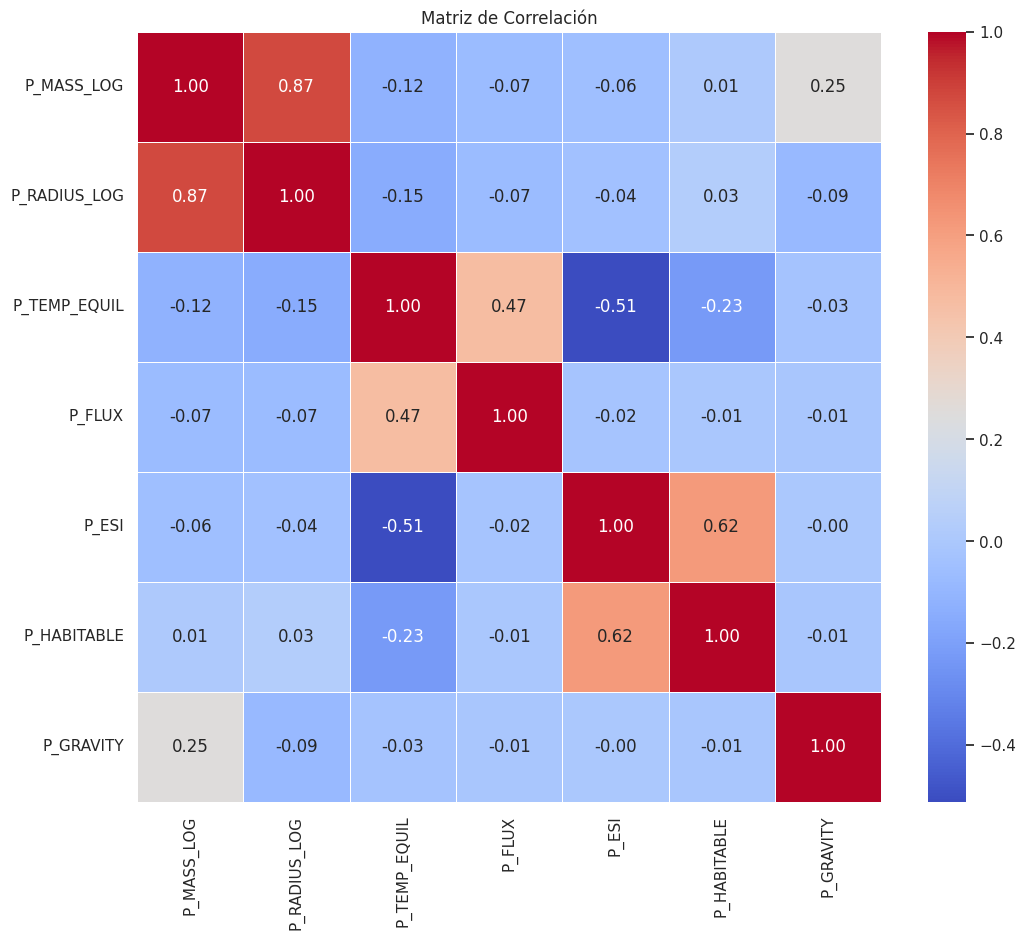

In [ ]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 10))

# Seleccionamos las columnas
columnas_interes = ['P_MASS_LOG', 'P_RADIUS_LOG', 'P_TEMP_EQUIL', 'P_FLUX', 'P_ESI', 'P_HABITABLE', 'P_GRAVITY']
corr = df_norm[columnas_interes].corr()

# Dibujamos la matriz
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación')

plt.show()

Esta matriz destaca que el ESI está fuertemente correlacionado con el índice de habitabilidad ($r=0.62$), lo que demuestra que, aunque no se usan los mismos cálculos, el ESI es un predictor confiable. Sin embargo, no son equivalentes. El ESI es gobernado primordialmente por la temperatura de equilibrio ($r=-0.51$), posicionando al balance térmico como el filtro más crítico. Existe un acoplamiento casi perfecto entre masa y radio ($r=0.87$), confirmando la consistencia física del catálogo. Por el contrario, la gravedad muestra una correlación nula con el ESI ($r=0.00$), indicando que la puntuación de similitud es mucho más sensible a la energía recibida y a las dimensiones básicas que a la fuerza gravitatoria superficial.

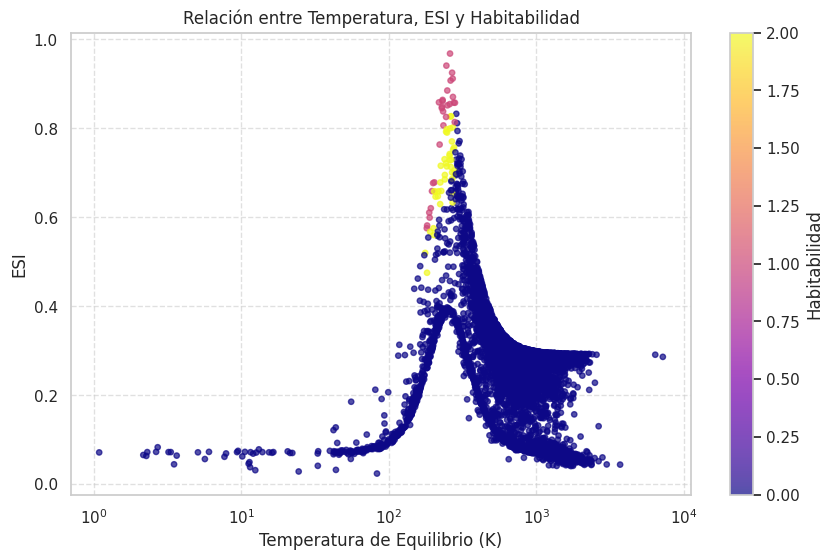

In [ ]:
plt.figure(figsize=(10, 6))
# Graficamos Temperatura vs ESI, el color indica si es habitable (0 o 1)
scatter = plt.scatter(df_clean["P_TEMP_EQUIL"], df_clean["P_ESI"],
                     c=df_clean["P_HABITABLE"], cmap="plasma", s=15, alpha=0.7)

plt.colorbar(scatter, label="Habitabilidad")
plt.xlabel("Temperatura de Equilibrio (K)")
plt.ylabel("ESI")
plt.xscale("log") # Escala logarítmica para manejar el rango extremo de temperaturas
plt.title("Relación entre Temperatura, ESI y Habitabilidad")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

La relación entre la temperatura de equilibrio y el ESI muestra un decaimiento acelerado: el índice de similitud solo alcanza valores óptimos ($> 0.8$) en un rango muy limitado de la escala de temperatura, situado cerca del extremo inferior (planetas fríos o templados). Existe una correlación negativa moderada ($\approx -0.51$), indicando que a medida que la temperatura aumenta, la probabilidad de mantener un ESI alto disminuye de forma no lineal. Los planetas clasificados como habitables (niveles 1 y 2, puntos amarillos y rosas) se agrupan en una "columna/línea de habitabilidad", sugieriendo que para estos mundos, la temperatura es el factor de control más duro. Cualquier desviación mínima hacia la derecha resulta en una caída drástica del ESI.

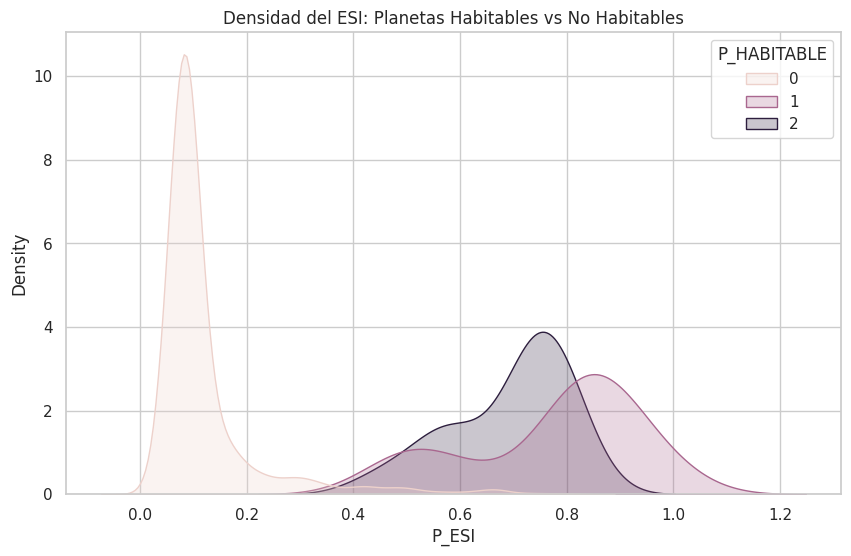

In [ ]:
# Comparación de distribuciones: Habitables vs No Habitables
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_norm, x='P_ESI', hue='P_HABITABLE', fill=True, common_norm=False)
plt.title('Densidad del ESI: Planetas Habitables vs No Habitables')

plt.show()

La visualización de densidad muestra una separación estadística contundente entre los planetas no habitables y los candidatos a contener vida. La población de nivel 0 (No Habitables) presenta una distribución concentrada en valores de ESI extremadamente bajos ($\approx 0.31$), lo que indica que la gran mayoría de los exoplanetas detectados poseen características físicas muy lejanas de las terrestres. En contraste, las distribuciones de los niveles 1 y 2 (zona optimista y conservadora) muestran un desplazamiento grande hacia la derecha, con promedios de ESI de $0.79$ y $0.74$ respectivamente. El nivel 1 presenta una distribución bimodal, puede que haya dos subgrupos distintos dentro de la zona optimista: uno con similitud moderada ($\approx 0.55$) y otro con una similitud terrestre excepcional que supera el $0.85$. Si bien un ESI alto es un fuerte indicador, no es el único factor determinante para la clasificación final de un planeta como "habitable conservador".

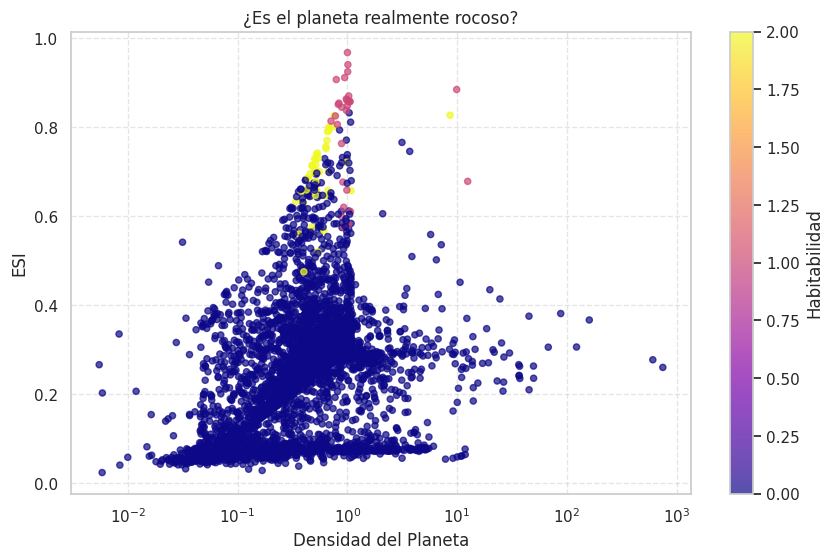

In [ ]:
plt.figure(figsize=(10, 6))

# El color (c) muestra qué planetas el dataset ya marca como habitables
plt.scatter(df_clean["P_DENSITY"], df_clean["P_ESI"],
            c=df_clean["P_HABITABLE"], cmap="plasma", s=20, alpha=0.7)

plt.colorbar(label="Habitabilidad")

plt.xscale("log")

plt.xlabel("Densidad del Planeta")
plt.ylabel("ESI")
plt.title("¿Es el planeta realmente rocoso?")
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

Se visualiza que la densidad nos indica si el planeta cuenta con una superficie sólida donde la vida pueda prosperar. Los planetas que muestran una convergencia entre densidad terrestre y alto ESI representan una alta probabilidad de habitabilidad, en el intervalo 0.4 - 0.8
 de ESI se confirma la existencia de una superficie litosférica (rocosa), requisito indispensable para el mantenimiento de agua líquida y, por ende, para la habitabilidad biológica.

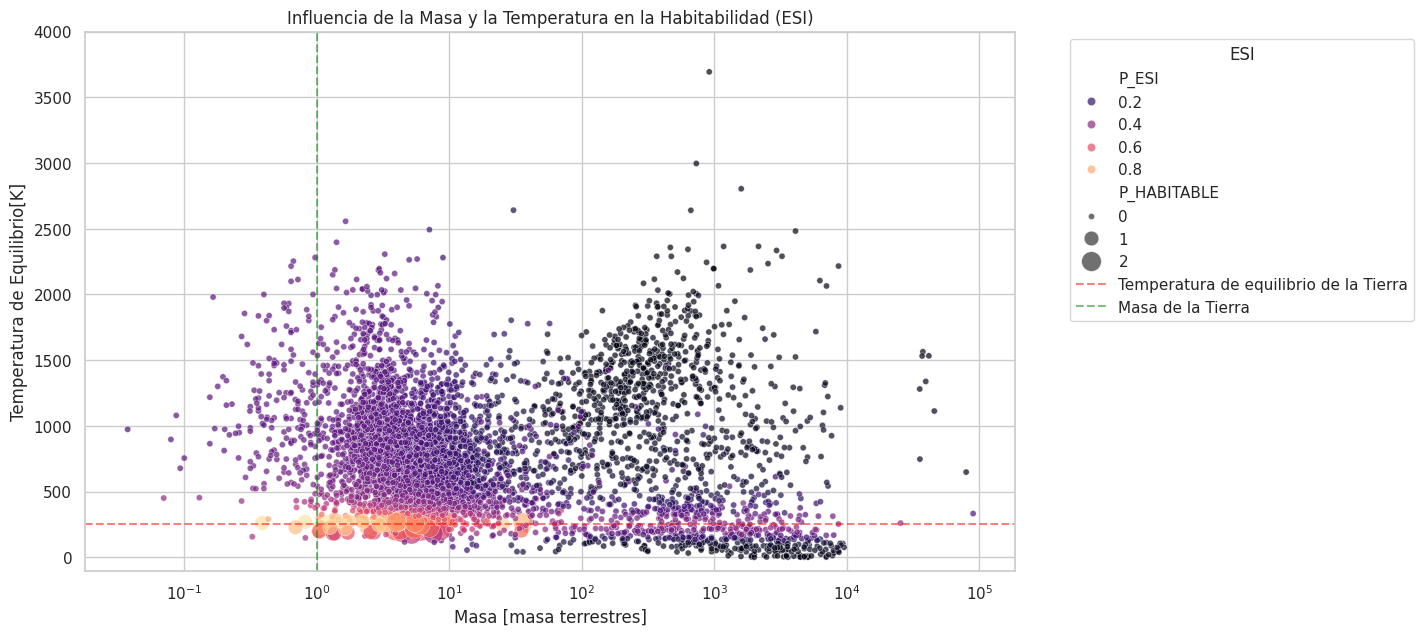

In [ ]:
# Masa, Temperatura y ESI
plt.figure(figsize=(12, 7))
bubble_plot = sns.scatterplot(
    data=df_clean,
    x='P_MASS',
    y='P_TEMP_EQUIL',
    size='P_HABITABLE',
    hue='P_ESI',
    palette='magma',
    sizes=(20, 200),
    alpha=0.7
)
plt.xscale('log')
plt.axhline(y=255, color="red", linestyle="--", label = "Temperatura de equilibrio de la Tierra", alpha = 0.5)
plt.axvline(x=1.0, color="green", linestyle="--", label = "Masa de la Tierra", alpha = 0.5)
plt.ylim(-100,4000)
plt.title('Influencia de la Masa y la Temperatura en la Habitabilidad (ESI)')
plt.xlabel('Masa [masa terrestres]')
plt.ylabel('Temperatura de Equilibrio[K]')
plt.legend(title='ESI', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

Se observa una franja de habitabilidad horizontal en la base del eje Y hasta aproximadamente las $\ 10^2$ masas terrestres, donde las burbujas de color claro (ESI > 0.8) y de mayor tamaño (Habitabilidad > 0.5) se concentran solo en niveles de temperatura muy bajos y estables. La masa muestra una distribución mucho más dispersa, por lo que hay candidatos con alta similitud terrestre tanto en masas pequeñas como en más masivas, siempre y cuando su temperatura se mantenga dentro del rango crítico. La fuerte correlación negativa entre la temperatura y el ESI ($\approx -0.51$) muestra que, en este dataset un planeta puede tener una masa ideal, pero si su temperatura se aleja del punto de equilibrio terrestre, su índice de similitud colapsa inmediatamente.

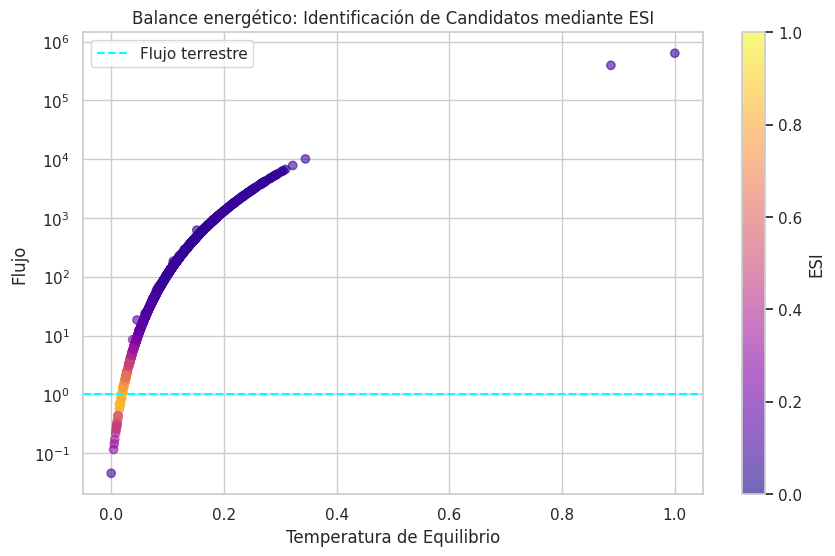

In [ ]:
# Flujo vs Temperatura
plt.figure(figsize=(10, 6))
plt.scatter(df_norm['P_TEMP_EQUIL'], df_analogos['P_FLUX'], c=df_norm['P_ESI'], cmap='plasma', alpha=0.6)
plt.yscale('log')
plt.colorbar(label='ESI')
plt.axhline(y=1.0, color='cyan', linestyle='--', label='Flujo terrestre')
plt.title('Balance energético: Identificación de Candidatos mediante ESI')
plt.xlabel('Temperatura de Equilibrio')
plt.ylabel('Flujo')
plt.legend()
plt.show()

La correlación entre el flujo y la temperatura de los planetas nos muestra su perfil térmico; se aprecia una dependencia exponencial donde pequeños incrementos en el flujo recibido elevan drásticamente la temperatura superficial. En el gráfico, el ESI alcanza sus valores máximos (puntos amarillos) exclusivamente en la intersección del flujo cercano a $1.0$ flujo terrestre y temperaturas en el rango de los $250\text{ K}$ a $300\text{ K}$, validando que la zona de habitabilidad puede denominarse como "circulo termico cerrado", un área muy pequeña en el gran espectro de datos. Como es de esperar por la definición matemática del ESI, a medida que los planetas se desplazan hacia flujos superiores a $10^1$, dicho índice colapsa por debajo de $0.4$.

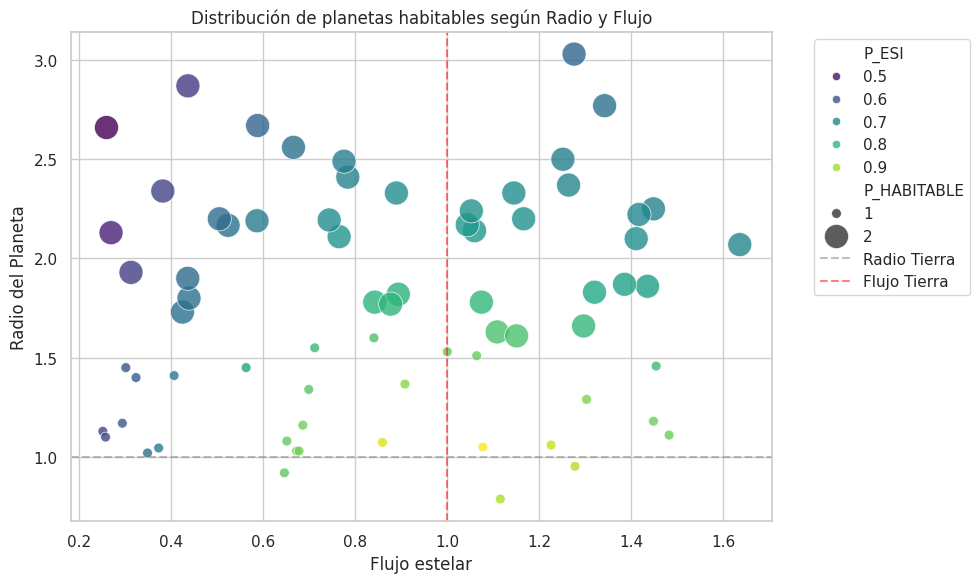

In [ ]:
# 1 y 2 como habitables
df_hab = df_clean[df_clean['P_HABITABLE'] > 0].copy()

# Radio vs Flujo Estelar
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_hab,
    x='P_FLUX',
    y='P_RADIUS',
    hue='P_ESI',
    size='P_HABITABLE',
    palette='viridis',
    sizes=(50, 300),
    alpha=0.8)

plt.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='Radio Tierra')
plt.axvline(x=1.0, color='red', linestyle='--', alpha=0.5, label='Flujo Tierra')

plt.title('Distribución de planetas habitables según Radio y Flujo')
plt.xlabel('Flujo estelar')
plt.ylabel('Radio del Planeta')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

In [ ]:
# Definimos los grupos por flujo respecto a la tierra
izquierdo = df[df['P_FLUX'] < 1.0]
derecho = df[df['P_FLUX'] >= 1.0]

# Contamos cuántos de nivel 2 hay en cada lado
print(f"Nivel 2 - Izquierdo: {len(izquierdo[izquierdo['P_HABITABLE'] == 2])}")
print(f"Nivel 2 - Derecho: {len(derecho[derecho['P_HABITABLE'] == 2])}")

# Buscamos ESI muy alto
top_izq = izquierdo[izquierdo['P_ESI'] > 0.85]
top_der = derecho[derecho['P_ESI'] > 0.85]

print(f"ESI (>0.85) - Izquierdo: {len(top_izq)}")
print(f"ESI (>0.85) - Derecho: {len(top_der)}")


Nivel 2 - Izquierdo: 21
Nivel 2 - Derecho: 20
ESI (>0.85) - Izquierdo: 5
ESI (>0.85) - Derecho: 9


Al contrastar el gráfico con la matriz se evidencia que la falta de relación lineal entre el flujo y el ESI proviene del ruido de los 4.000 registros de nuestro dataset. El gráfico muestra que los candidatos con mayor similitud terrestre se agrupan en solo una estrecha ventana de energía cercana al 1.0, fuera de la cual el ESI colapsa. No obstante, dado a que esta tendencia se apoya en una muestra minúscula de planetas no tomaremos estos patrones como leyes definitivas, debido a la alta sensibilidad del análisis ante una población reducida.

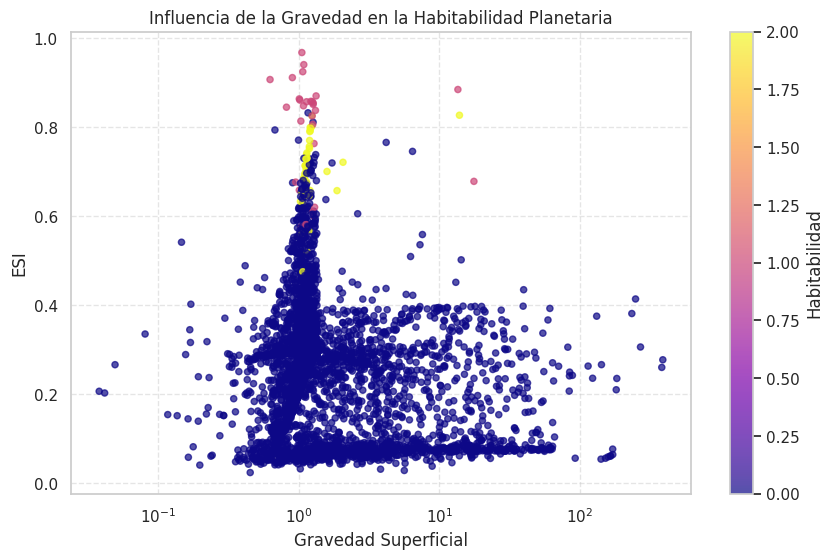

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(df_clean["P_GRAVITY"], df_clean["P_ESI"],
            c=df_clean["P_HABITABLE"], cmap="plasma", s=20, alpha=0.7)

plt.colorbar(label="Habitabilidad")

plt.xscale("log")
plt.xlabel("Gravedad Superficial")
plt.ylabel("ESI")
plt.title("Influencia de la Gravedad en la Habitabilidad Planetaria")
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

Una gravedad similar a la terrestre no solo es un componente del cálculo del ESI, sino que es el factor determinante para la retención de una atmósfera secundaria adecuada para la vida. Los datos muestran que los candidatos con mayor potencial de habitabilidad se concentran en un rango estrecho entre $0.8\text{g}$ y $1.5\text{g}$ (donde $\text{g}$ es la gravedad terrestre), lo que sugiere que planetas fuera de este umbral, aunque tengan temperaturas adecuadas, enfrentarían dificultades para mantener condiciones estables de presión y protección contra la radiación estelar.

# 4. Discusión e interpretación

En la matriz de correlación destacan principalmente la temperatura de equilibrio de los planetas y el indice de habitabilidad debido a su estrecha relación con el ESI, variable que es el foco principal del presente análisis.

El análisis exploratorio, la matriz de correlación y las visualizaciones elaboradas muestran que el ESI presenta correlación directa con numerosas variables que son de interés a la hora de estudiar la habitabilidad de un planeta, como la gravedad y el flujo. En particular, es posible advertir que los gráficos en los que se utiliza la temperatura de equilibrio muestran interesantes relaciones entre variables y tendencias, además de que la misma en sí constituye una distintición fundamental para identificar la viabilidad biológica real y actuar como filtro de control,una visión interesante que podría ser explorada en un trabajo futuro.

Considerando la importancia de tener en cuenta otros factores, puede afirmarse que, si se buscan resultados fidedignos y contundentes, el ESI no debería ser el unico parámetro considerado al buscar planetas habitables; este indice no contempla aspectos como la composición química del planeta, la presencia de agua liquida, el campo magnético, entre otros. Es factible, por tanto, que un planeta tenga un ESI elevado pero no cumpla con otros factores que son considerados esenciales para el desarrollo de la vida.

Basándonos en el analisis podriamos considerar que el indice de habitabilidad no es equivalente al ESI, por lo que podría ser usado como complemento al mismo en la formación de un criterio de filtrado para encontrar planetas que puedan considerarse habitables.


### Patrones

- La temperatura de equilibrio de los planetas habitables tanto de una perspectiva optimista como de una conservadora tienden a rodear la temperatura de equilibrio terrestre estando el grupo ligeramente mas poblado por el lado inferior, los planetas de nivel 2 se observan mas condensados que los de nivel 1 tanto en temperatura de equilibrio como en ESI y con el flujo existe una relación muy parecida. Esto es de esperar, ya que la temperatura de equilibrio de un planeta es consecuencia directa del flujo que recibe éste.

- La densidad de los planetas más habitables tiende a ser ligeramente menor que la de la Tierra, a diferencia de los planetas con ESI mayor, los que en su mayoria coinciden aproximadamente con la densidad de la Tierra.

- La masa de los planetas con mayor ESI tiende a la masa terrestre a diferencia de los mas habitables que se parecen tender a 10 masas terrestres, lo que implica que son mas masivos pero menos densos al relacionar este patron con el mencionado sobre la densidad.

- Los planetas con mayor habitabilidad tienen radios superiores a 1.5 radios terrestres, mientras que los de mayor ESI se concentran en radios cercanos o inferiores a 1.5 radios terrestres, lo que refuerza la idea de que ESI alto y habitabilidad alta no coinciden necesariamente en las mismas propiedades físicas.

- Los planetas con indice de habitabilidad 2 tienden a un ESI mayor que 0.6 pero menor que 0.8 y los que tienen nivel 1 en general tienen un ESI de 0.8 o mayor, lo que parece sugerir que si se quisiera encontrar la mayor cantidad de planetas habitables se deberia centrar en ese rango de ESI, esto teniendo cuenta que la cantidad de candidatos habitables de esta base de datos si se toman en cuenta solo estos 2 parametros es bastante reducida para poder interpretar cualquier conclusión estadistica seria.





In [ ]:
#ecnotramos los planetas con masas parecidas a la tierra
masa_men_t_i = df_clean['P_MASS'] < 2
masa_may_t_i = df_clean['P_MASS'] > 0.1

masa_men_t = df_clean[masa_men_t_i]
masas = masa_men_t[masa_may_t_i]

# Hacemos lo mismo con el radio, para quedarnos con planetas rocosos
radio_men_t_i = df_clean['P_RADIUS'] < 1.5
radio_may_t_i = df_clean['P_RADIUS'] > 0.5
radio_men_t = df_clean[radio_men_t_i]
radio = radio_men_t[radio_may_t_i]
# Ahora, nos quedamos con los planetas que cumplen ambas condiciones
planetas_rocky = df_clean[(df_clean['P_MASS'] < 2) & (df_clean['P_MASS'] > 0.1) & (df_clean['P_RADIUS'] < 1.5) & (df_clean['P_RADIUS'] > 0.5)]
print("Planetas rocosos (Masa entre 0.1 y 2, Radio entre 0.5 y 1.5):", len(planetas_rocky))

# ahora hacemos lo mismo pero con el flujo
flujo_men_t_i = df_clean['P_FLUX'] < 2
flujo_may_t_i = df_clean['P_FLUX'] > 0.5

flujo_men_t = df_clean[flujo_men_t_i]
flujo = flujo_men_t[flujo_may_t_i]
# ahora hacemos lo msimo pero con la temperatura
temp_men_t_i = df_clean['P_TEMP_EQUIL'] < 350
temp_may_t_i = df_clean['P_TEMP_EQUIL'] > 150
temp_men_t = df_clean[temp_men_t_i]
temp = temp_men_t[temp_may_t_i]
# Finalmente, nos quedamos con los planetas que cumplen con el flujo y la temperatura
planetas_hab = df_clean[(df_clean['P_FLUX'] < 2) & (df_clean['P_FLUX'] > 0.5) & (df_clean['P_TEMP_EQUIL'] < 350) & (df_clean['P_TEMP_EQUIL'] > 150)]
print("Planetas con flujo entre 0.5 y 2, y temperatura entre 150K y 350K:", len(planetas_hab))

respuesta = planetas_rocky['P_NAME'].isin(planetas_hab['P_NAME'])
planetas_rocky_hab = planetas_rocky[respuesta]
print("Planetas rocosos que también cumplen con las condiciones de flujo y temperatura:", len(planetas_rocky_hab))

Planetas rocosos (Masa entre 0.1 y 2, Radio entre 0.5 y 1.5): 463
Planetas con flujo entre 0.5 y 2, y temperatura entre 150K y 350K: 258
Planetas rocosos que también cumplen con las condiciones de flujo y temperatura: 16


/tmp/ipykernel_6771/2567317218.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  masas = masa_men_t[masa_may_t_i]
/tmp/ipykernel_6771/2567317218.py:12: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  radio = radio_men_t[radio_may_t_i]
/tmp/ipykernel_6771/2567317218.py:22: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  flujo = flujo_men_t[flujo_may_t_i]
/tmp/ipykernel_6771/2567317218.py:27: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  temp = temp_men_t[temp_may_t_i]


¿Los planetas parecidos a la Tierra en masa y radio también lo son en temperatura y flujo?

La respuesta es que en general no los planetas con densidad parecida a la tierra no tienen flujos y temperaturas parecidas a la tierra

## 5. Selección de candidatos
Finalmente, ordenamos los valores según mayor a menor ESI y escogemos los primeros tres, ya que el objetivo del trabajo era identificar candidatos que se aproximen a la tierra en el aspecto fisico, por ende nos concentramos únicamente en relaciones físicas, más no implica que sean automáticamente apropiados para la habitabilidad.
Es por esto que consideramos que la selección de planetas mediante este método es ineficiente y requiere de más métodos acompañantes.



In [ ]:
eresort_df = df_clean.sort_values("P_ESI", ascending=False)
eresort_df.head(3)

,P_NAME,P_HABITABLE,P_MASS,P_RADIUS,P_DENSITY,P_GRAVITY,P_FLUX,P_TEMP_EQUIL,P_ESI
934,Teegarden's Star b,1,1.16,1.050,1.002052,1.052154,1.077943,259.52272,0.968362
537,TOI-700 d,1,1.25,1.073,1.011838,1.085702,0.859827,245.22160,0.941176
1291,Kepler-1649 c,1,1.20,1.060,1.007543,1.067996,1.226057,268.05713,0.925298


Los candidatos seleccionados son:
*1. Teegarden's Star b — ESI: 0.968*  
El candidato más parecido a la Tierra en todo el catálogo. Con una masa de 1.16 masas terrestres,
radio de 1.05 y densidad prácticamente idéntica a la Tierra (1.00), representa el planeta más similar al nuestro. Su temperatura de equilibrio de 260 K y flujo de 1.08 flujos terrestres lo ubican
en el borde cálido de la zona habitable optimista, con condiciones térmicas compatibles con agua líquida.

*2. TOI-700 d — ESI: 0.941*  
Presenta la temperatura de equilibrio más baja de los tres (245 K arpox) y el flujo más cercano al terrestre (0.86), lo que lo tranforma en un candidato favorable en el aspecto energético. Su densidad (1.01) y gravedad (1.09)
se acercan mucho a las terrestres, reforzando su perfil como análogo rocoso. Es el candidato más
"frío" de los seleccionados, pero dentro del rango compatible con agua líquida bajo ciertas condiciones atmosféricas.

*3. Kepler-1649 c — ESI: 0.925*  
Aunque recibe un flujo algo mayor (1.23), su temperatura de equilibrio moderada (268 K) y su densidad terrestre (1.01) lo mantienen como un candidato sólido. Su gravedad de 1.07g es la más alta del grupo, lo que sugiere buena capacidad de retención atmosférica. Es el más cálido de los tres, pero aún dentro del rango habitable optimista.

Los tres candidatos comparten densidades muy cercanas a 1.0 (en unidades terrestres), lo que confirma su naturaleza rocosa y consistencia física con la Tierra. Reconocemos que esta selección está acotada
al marco físico del ESI y, por lo tanto, puede presentar limitaciones.

Por otro lado, para complementar la selección combinamos el ESI y el índice de habitabilidad PHI, a fin de implementar un criterio propio. Así, podemos tener ambos números en consideración si es que seleccionamos planetas con habitabilidad 2 (habitable, con un estándar conservador)

In [ ]:
# Planetas con los mayores ESI
Top_ESI_index = df_clean['P_ESI'] >= 0.8
Top_ESI_planets = df_clean[Top_ESI_index]

# indexamos los planetas con indice de habitabilidad 2
Top_Hab_index = df_clean['P_HABITABLE'] == 2
Top_planetas = Top_ESI_planets[Top_Hab_index]
print("Planetas con ESI >= 0.8 y Habitabilidad = 2:",len(Top_planetas))
Top_planetas.head()

Planetas con ESI >= 0.8 y Habitabilidad = 2: 3


/tmp/ipykernel_6771/734080397.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  Top_planetas = Top_ESI_planets[Top_Hab_index]


,P_NAME,P_HABITABLE,P_MASS,P_RADIUS,P_DENSITY,P_GRAVITY,P_FLUX,P_TEMP_EQUIL,P_ESI
1210,Kepler-452 b,2,3.29,1.63,0.759684,1.238285,1.109013,261.41702,0.826719
2283,Wolf 1061 c,2,3.41,1.66,0.745470,1.237480,1.296772,271.22218,0.802188
2601,Kepler-62 e,2,36.00,1.61,8.626306,13.888353,1.151183,263.86742,0.827428


Puede verse que, al considerar el PHI, los candidatos idóneos cambian, y pasan a ser planetas cuyo ESI está algo más alejado del número 1, esto invita, nuevamente, a cuestionar la efectividad del ESI por sí solo como métrica para medir habitabilidad de un planeta.

## 6. Conclusiones

El objetivo fue explorar el catálogo del Habitable Worlds Catalog (HWC) desde el punto de vista de los análogos terrestres.
Se utilizó el criterio Earth Similarity Index (ESI) para identificar candidatos a planetas habitables que comparten similitudes físicas con la Tierra.

Como demuestra el análisis realizado con los datos de HWC, existe una gran cantidad de variables a considerar al momento de definir si es que un planeta es habitable o no. Nuestro trabajo muestra que el ESI es una métrica relevante para este propósito, útil y estadísticamente coherente, pero que por sí sola no es suficiente para determinar la habitabilidad de un planeta. Puede ser un buen punto de inicio, dada su fuerte correlación con otras variables que se usan para analizar la posible capacidad de un exoplaneta de albergar vida, pero es recomendado utilizar más criterios (como por ejemplo, la temperatura de equilibrio) para lograr una buena categorización de planetas habitables.

# 7. Referencias

*Disclaimer:* Para la elaboración de este trabajo fue utilizada la inteligencia artificial Claude para complementar el análisis de datos. Se utilizó la inteligencia artificial Gemini para comprender el análisis del gráfico "Flujo-Radio"